In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import coupled_label_plot, color_code_labels
from utils.analysis import get_query_string_hyps_filter, prepare_labels_df, rotate_umap, load_dbscan_labels

In [2]:
# Plot settings
xmap = {"n_clusters": "Number of clusters", "eps": "Epsilon", "min_samples": "Minimum number of samples"}
score_name_map = {"calinski_harabasz": "Calinski-Harabasz Score", "silhouette": "Silhouette Score", "davies_bouldin": "Davies-Bouldin Score", "nnoise": "Noise [%]", "nclusters": "Number of Clusters",
                 "kdbcv": "k-DBCV", "cdr": "CDR", "cvnn_hal": "CVNNH"}
c_blue = sns.color_palette("tab10")[0]
c_orange = sns.color_palette("tab10")[1]

In [3]:
def plot_score(df, x, legend_loc=None):
    """ Plot Calinski-Harabasz, Silhouette and Davies-Bouldin scores as line plots. """
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8.27, 8.27*0.6))
    axs = axs.flatten()

    # Plot lines
    l1 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="calinski_harabasz", ax=axs[0], c=c_blue, label="MinMax")
    l2 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="davies_bouldin", ax=axs[1], c=c_blue, label="MinMax")
    l3 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="silhouette", ax=axs[2], c=c_blue, label="MinMax")
    
    l4 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="calinski_harabasz", ax=axs[0], c=c_orange, label="MinMax-UMAP")
    l5 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="davies_bouldin", ax=axs[1], c=c_orange, label="MinMax-UMAP")
    l6 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="silhouette", ax=axs[2], c=c_orange, label="MinMax-UMAP")

    l7 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="kdbcv", ax=axs[3], c=c_blue, label="MinMax")
    l8 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="cvnn_hal", ax=axs[4], c=c_blue, label="MinMax")
    l9 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="cdr", ax=axs[5], c=c_blue, label="MinMax")

    l10 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="kdbcv", ax=axs[3], c=c_orange, label="MinMax-UMAP")
    l11 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="cvnn_hal", ax=axs[4], c=c_orange, label="MinMax-UMAP")
    l12 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="cdr", ax=axs[5], c=c_orange, label="MinMax-UMAP")
   
    # Define labels
    l1.set_xlabel(None)
    l1.set_ylabel(None)
    l1.set_title(r"Calinski-Harabasz Score $\uparrow$", fontsize=11)
    l1.tick_params(labelsize=8)
    l1.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l2.set_xlabel(None)
    l2.set_ylabel(None)
    l2.set_title(r"Davies-Bouldin Score $\downarrow$", fontsize=11)
    l2.tick_params(labelsize=8)
    l2.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l3.set_xlabel(None)
    l3.set_ylabel(None)
    l3.set_title(r"Silhouette Score $\uparrow$", fontsize=11)
    l3.tick_params(labelsize=8)
    l3.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l7.set_xlabel(None)
    l7.set_ylabel(None)
    l7.set_title(r"k-DBCV $\uparrow$", fontsize=11)
    l7.tick_params(labelsize=8)
    # l7.set_yticks([])
    l7.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l8.set_xlabel(None)
    l8.set_ylabel(None)
    l8.set_title(r"CVNNH $\downarrow$", fontsize=11)
    l8.tick_params(labelsize=8)
    l8.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l9.set_xlabel(None)
    l9.set_ylabel(None)
    l9.set_title(r"CDR $\downarrow$", fontsize=11)
    l9.tick_params(labelsize=8)
    l9.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    fig.supxlabel(xmap[x], fontsize=11, y=0.04)
    
    plt.tight_layout()

In [4]:
def find_steepest_gradient(df, value_col="calinski_harabasz"):
    """ Find steepest gradient for DBSCAN in an eps-min_samples heatmap using value_col as value column. """
    temp = df.copy()
    
    # Normalise columns for consistent scaling
    temp['eps_norm'] = (temp['eps'] - temp['eps'].min()) / (temp['eps'].max() - temp['eps'].min())
    temp['min_samples_norm'] = (temp['min_samples'] - temp['min_samples'].min()) / (temp['min_samples'].max() - temp['min_samples'].min())
    temp['calinski_norm'] = (temp[value_col] - temp[value_col].min()) / (temp[value_col].max() - temp[value_col].min())
    
    # Pivot to create a 2D grid
    grid = temp.pivot(index='min_samples_norm', columns='eps_norm', values='calinski_norm')
    grid = grid.interpolate(method='linear', axis=0).interpolate(method='linear', axis=1)  # Fill missing values

    # Calculate gradients
    grad_eps, grad_min_samples = np.gradient(grid.values)  # Numerical differentiation

    # Compute gradient magnitude
    grad_magnitude = np.sqrt(grad_eps**2 + grad_min_samples**2)

    # Find the index of the maximum gradient
    max_idx = np.unravel_index(np.argmax(grad_magnitude), grad_magnitude.shape)
    max_min_samples_norm = grid.index[max_idx[0]]
    max_eps_norm = grid.columns[max_idx[1]]

    # Map back to original scale
    max_eps = max_eps_norm * (temp['eps'].max() - temp['eps'].min()) + temp['eps'].min()
    max_min_samples = max_min_samples_norm * (temp['min_samples'].max() - temp['min_samples'].min()) + temp['min_samples'].min()

    return max_eps, max_min_samples

In [5]:
def plot_heatmap(df, x="min_samples", y="eps", color="nclusters", title="Sweep of DBSAN (on original data)", vmax=None, mask=None, annot=True, patch=None):
    """ Plot heatmap using 2 variables and compute steepest gradient. """
    df_temp = df.copy()
    df_temp = df_temp.sort_values([y, x])

    # Define heatmap fields
    idx = df_temp[y].unique()
    cols = df_temp[x].unique()
    field = pd.DataFrame(df_temp[color].to_numpy().reshape(len(idx), len(cols)), index=idx, columns=cols)

    # Apply mask (if some fields are not supposed to be shown)
    if mask is not None:
        field = field[mask]

    # Heatmap plot
    h = sns.heatmap(data=field, cbar_kws={'label': score_name_map[color]}, annot=annot, fmt='g', cmap="gray", vmax=vmax)
    plt.gca().invert_yaxis()
    if patch:
        h.add_patch(Rectangle((np.where(cols == patch[1])[0][0], np.where(idx == patch[0])[0][0]), 1, 1, fill=False, edgecolor="red", lw=2))
    plt.xlabel(x)  
    plt.ylabel(y) 
    plt.title(title)  
    plt.tick_params(axis='both', which='minor')  
    plt.tight_layout()

    # Compute steepest gradient
    steepest_gradient_eps, steepest_gradient_min_samples = find_steepest_gradient(df, value_col=color)

    return field, (steepest_gradient_eps, steepest_gradient_min_samples)

# Load data

In [6]:
# Load scores
df_kmeans = pd.read_csv(f"{config.output_dir_clustering}internal_validation_kmeans.csv")
df_ward = pd.read_csv(f"{config.output_dir_clustering}internal_validation_ward.csv")
df_dbscan = pd.read_csv(f"{config.output_dir_clustering}internal_validation_dbscan.csv")
df_spatial = pd.read_csv(f"{config.output_dir_clustering}internal_validation_spatial_ward.csv")

In [7]:
# Load labels (from iteration 0, store labels from different preproccessings in different columns)
df_kmeans_labels = pd.read_csv(f"{config.output_dir_clustering}labels_kmeans.csv")
df_kmeans_labels = prepare_labels_df(df_kmeans_labels, iteration=0)

df_ward_labels = pd.read_csv(f"{config.output_dir_clustering}labels_ward.csv")
df_ward_labels = prepare_labels_df(df_ward_labels, iteration=0)

df_dbscan_labels = load_dbscan_labels(iteration=0)
df_dbscan_labels = prepare_labels_df(df_dbscan_labels)

df_spatial_labels = pd.read_csv(f"{config.output_dir_clustering}labels_spatial_ward.csv")
df_spatial_labels = prepare_labels_df(df_spatial_labels, iteration=0)

# Compare across algorithms
Using the finally selected hyperparameter combinations, compare the CVIs for the algorithms. 

In [8]:
# Filter the score data for the final hyperparameter combinations
# Kmeans original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.kmeans_original_hyps, preproc="minmax")
ko = df_kmeans.query(query_str)

# Kmeans embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.kmeans_umap_hyps, preproc="minmax_umap")
ke = df_kmeans.query(query_str)

# Ward original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.ward_original_hyps, preproc="minmax")
wo = df_ward.query(query_str)

# Ward embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.ward_umap_hyps, preproc="minmax_umap")
we = df_ward.query(query_str)

# DBSCAN original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_original_hyps, preproc="minmax", float_tol=1e-8)
do = df_dbscan.query(query_str)

# DBSCAN embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_umap_hyps, preproc="minmax_umap", float_tol=1e-8)
de = df_dbscan.query(query_str)

# Spatial Ward original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.spatial_original_hyps, preproc="minmax", float_tol=1e-8)
so = df_spatial.query(query_str)

# Spatial ward embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.spatial_umap_hyps, preproc="minmax_umap", float_tol=1e-8)
se = df_spatial.query(query_str)

In [9]:
print("Average scores")
print("\nKMeans on original: ")
print(f'  Calinski-Harabasz: {ko["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {ko["davies_bouldin"].mean().round(2)}\n  Silhouette: {ko["silhouette"].mean().round(2)}\n  k-DBCV: {ko["kdbcv"].mean()}\n  CVNN Halkidi: {ko["cvnn_hal"].mean().round(2)}\n  CDR: {ko["cdr"].mean().round(2)}')
print("\nKMeans on UMAP: ")
print(f'  Calinski-Harabasz: {ke["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {ke["davies_bouldin"].mean().round(2)}\n  Silhouette: {ke["silhouette"].mean().round(2)}\n  k-DBCV: {ke["kdbcv"].mean()}\n  CVNN Halkidi: {ke["cvnn_hal"].mean().round(2)}\n  CDR: {ke["cdr"].mean().round(2)}')

print("\nWard on original: ")
print(f'  Calinski-Harabasz: {wo["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {wo["davies_bouldin"].mean().round(2)}\n  Silhouette: {wo["silhouette"].mean().round(2)}\n  k-DBCV: {wo["kdbcv"].mean()}\n  CVNN Halkidi: {wo["cvnn_hal"].mean().round(2)}\n  CDR: {wo["cdr"].mean().round(2)}')
print("\nWard on UMAP: ")
print(f'  Calinski-Harabasz: {we["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {we["davies_bouldin"].mean().round(2)}\n  Silhouette: {we["silhouette"].mean().round(2)}\n  k-DBCV: {we["kdbcv"].mean()}\n  CVNN Halkidi: {we["cvnn_hal"].mean().round(2)}\n  CDR: {we["cdr"].mean().round(2)}')

print("\nDBSCAN on original: ")
print(f'  Calinski-Harabasz: {do["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {do["davies_bouldin"].mean().round(2)}\n  Silhouette: {do["silhouette"].mean().round(2)}\n  k-DBCV: {do["kdbcv"].mean()}\n  CVNN Halkidi: {do["cvnn_hal"].mean().round(2)}\n  CDR: {do["cdr"].mean().round(2)}')
print("\nDBSCAN on UMAP: ")
print(f'  Calinski-Harabasz: {de["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {de["davies_bouldin"].mean().round(2)}\n  Silhouette: {de["silhouette"].mean().round(2)}\n  k-DBCV: {de["kdbcv"].mean()}\n  CVNN Halkidi: {de["cvnn_hal"].mean().round(2)}\n  CDR: {de["cdr"].mean().round(2)}')

print("\nSpatial Ward on original: ")
print(f'  Calinski-Harabasz: {so["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {so["davies_bouldin"].mean().round(2)}\n  Silhouette: {so["silhouette"].mean().round(2)}\n  k-DBCV: {so["kdbcv"].mean()}\n  CVNN Halkidi: {so["cvnn_hal"].mean().round(2)}\n  CDR: {so["cdr"].mean().round(2)}')
print("\nSpatial Ward on UMAP: ")
print(f'  Calinski-Harabasz: {se["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {se["davies_bouldin"].mean().round(2)}\n  Silhouette: {se["silhouette"].mean().round(2)}\n  k-DBCV: { se["kdbcv"].mean()}\n  CVNN Halkidi: {se["cvnn_hal"].mean().round(2)}\n  CDR: {se["cdr"].mean().round(2)}')

Average scores

KMeans on original: 
  Calinski-Harabasz: 57358.0
  Davies-Bouldin: 0.78
  Silhouette: 0.5
  k-DBCV: -1.0
  CVNN Halkidi: 0.24
  CDR: 0.57

KMeans on UMAP: 
  Calinski-Harabasz: 49703.0
  Davies-Bouldin: 0.71
  Silhouette: 0.47
  k-DBCV: -0.7778546880642049
  CVNN Halkidi: 3.55
  CDR: 0.6

Ward on original: 
  Calinski-Harabasz: 51825.0
  Davies-Bouldin: 0.84
  Silhouette: 0.48
  k-DBCV: -1.0
  CVNN Halkidi: 0.24
  CDR: 0.56

Ward on UMAP: 
  Calinski-Harabasz: 65901.0
  Davies-Bouldin: 0.72
  Silhouette: 0.46
  k-DBCV: -0.6145907221500421
  CVNN Halkidi: 1.73
  CDR: 0.59

DBSCAN on original: 
  Calinski-Harabasz: 800.0
  Davies-Bouldin: 1.44
  Silhouette: 0.55
  k-DBCV: -1.0
  CVNN Halkidi: 0.98
  CDR: 0.54

DBSCAN on UMAP: 
  Calinski-Harabasz: 1754.0
  Davies-Bouldin: 1.5
  Silhouette: -0.35
  k-DBCV: -0.40651715957814166
  CVNN Halkidi: 3.31
  CDR: 0.56

Spatial Ward on original: 
  Calinski-Harabasz: 51928.0
  Davies-Bouldin: 0.82
  Silhouette: 0.48
  k-DBCV: -1.0


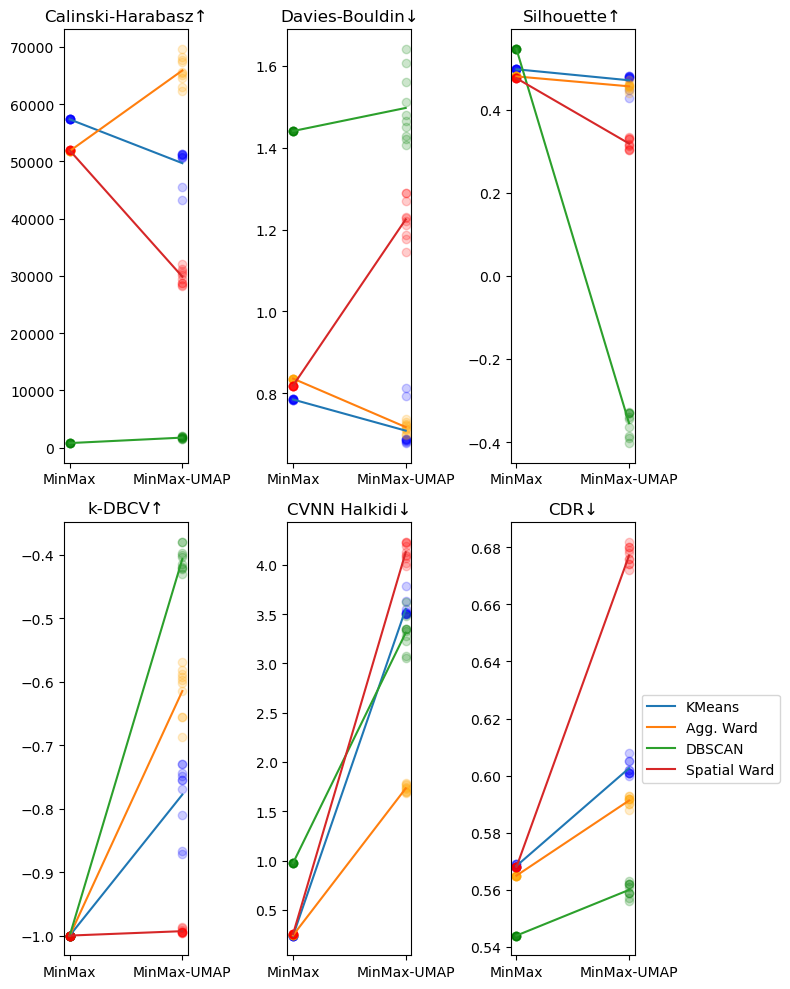

In [10]:
# Compare scores of clustering methods on both preprocessings (using final hyperparameters)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 10))
axs = axs.flatten()

alpha = 0.2
for i, score, score_name in [(0, "calinski_harabasz", "Calinski-Harabasz"), (1, "davies_bouldin", "Davies-Bouldin"), (2, "silhouette", "Silhouette"), 
                             (3, "kdbcv", "k-DBCV"), (4, "cvnn_hal", "CVNN Halkidi"), (5, "cdr", "CDR")]:
    title = score_name + "\u2191"
    if score_name == "Davies-Bouldin" or score_name == "CVNN Halkidi" or score_name == "CDR": 
        title = score_name + "\u2193"
    axs[i].set_title(title)
    axs[i].set_xticks([0, 1], ["MinMax", "MinMax-UMAP"])

    axs[i].scatter([0]*len(ko), ko[score], color="blue", alpha=alpha)
    axs[i].scatter([1]*len(ke), ke[score], color="blue", alpha=alpha)
    axs[i].plot([0, 1], [ko[score].mean(), ke[score].mean()], color="tab:blue", label="KMeans")

    axs[i].scatter([0]*len(wo), wo[score], color="orange", alpha=alpha)
    axs[i].scatter([1]*len(we), we[score], color="orange", alpha=alpha)
    axs[i].plot([0, 1], [wo[score].mean(), we[score].mean()], color="tab:orange", label="Agg. Ward")

    axs[i].scatter([0]*len(do), do[score], color="green", alpha=alpha)
    axs[i].scatter([1]*len(de), de[score], color="green", alpha=alpha)
    axs[i].plot([0, 1], [do[score].mean(), de[score].mean()], color="tab:green", label="DBSCAN")

    axs[i].scatter([0]*len(so), so[score], color="red", alpha=alpha)
    axs[i].scatter([1]*len(se), se[score], color="red", alpha=alpha)
    axs[i].plot([0, 1], [so[score].mean(), se[score].mean()], color="tab:red", label="Spatial Ward")
    
axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#plt.savefig(f"{config.output_dir_plots}score_comparison.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_comparison.png", dpi=1000)
plt.show()

In [11]:
pd.concat([ko, ke, wo, we, do, de]).drop(["n_init", "n_clusters", "linkage", "distance_threshold", "eps", "min_samples", "iteration", "nnoise"], axis=1) \
.groupby(["preprocessing", "clustering"]).mean()# .sort_values(["preprocessing", "silhouette"])

nclusters  clustering_time  score_time  confetti  \
preprocessing clustering                                                     
minmax        dbscan            4.0        11.411032   78.498173    25.000   
              kmeans            2.0         0.058801   64.336403     0.000   
              ward              2.0        48.399010   64.711141     0.000   
minmax_umap   dbscan          387.1        11.654863   66.276933    78.235   
              kmeans            8.0        11.396042  144.599767     0.000   
              ward             25.0        53.161868   72.967048     0.000   

                          silhouette  davies_bouldin  calinski_harabasz  \
preprocessing clustering                                                  
minmax        dbscan        0.545846        1.440487         799.580586   
              kmeans        0.497104        0.784804       57358.427179   
              ward          0.479916        0.835917       51824.792836   
minmax_umap   dbscan       -0.354580        1.496869        1754.321496   
              kmeans        0.470666        0.708782       49702.571652   
              ward          0.456141        0.717471       65901.029910   

                             kdbcv  cvnn_hal     cdr  
preprocessing clustering                              
minmax        dbscan     -1.000000    0.9760  0.5440  
              kmeans     -1.000000    0.2400  0.5684  
              ward       -1.000000    0.2430  0.5650  
minmax_umap   dbscan     -0.406517    3.3098  0.5600  
              kmeans     -0.777855    3.5507  0.6026  
              ward       -0.614591    1.7322  0.5913

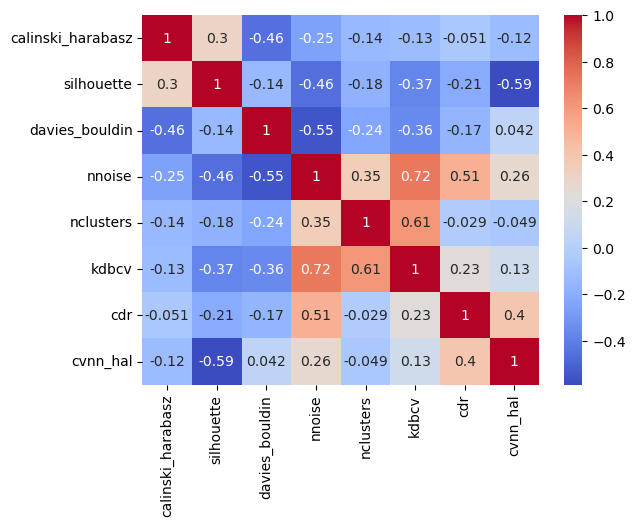

In [13]:
# Correlation between scores
final_all = pd.concat([df_kmeans, df_dbscan, df_ward, df_spatial])
sns.heatmap(final_all[score_name_map.keys()].corr(), cmap="coolwarm", annot=True)
plt.show()

# KMeans

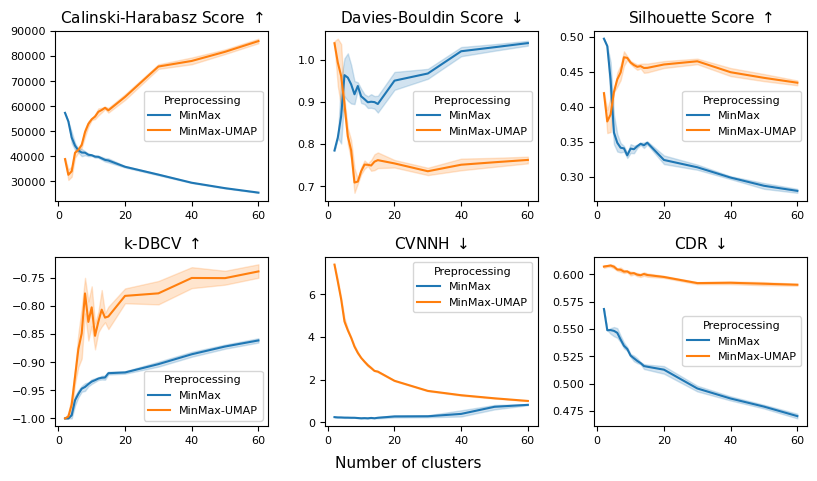

In [49]:
plot_score(df_kmeans, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_kmeans.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_kmeans.png", dpi=1000)
plt.show()

## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


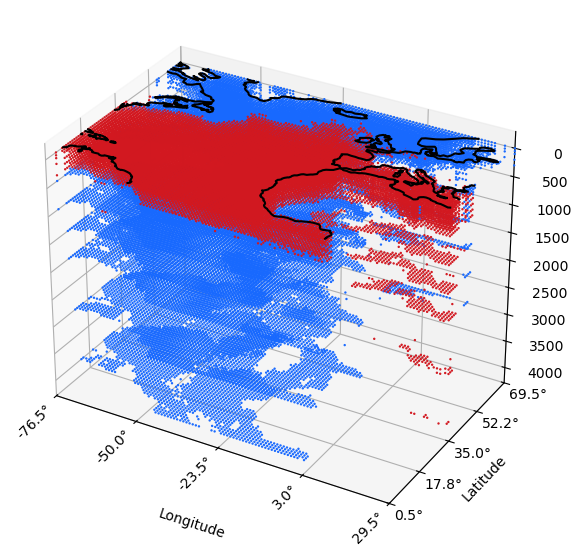

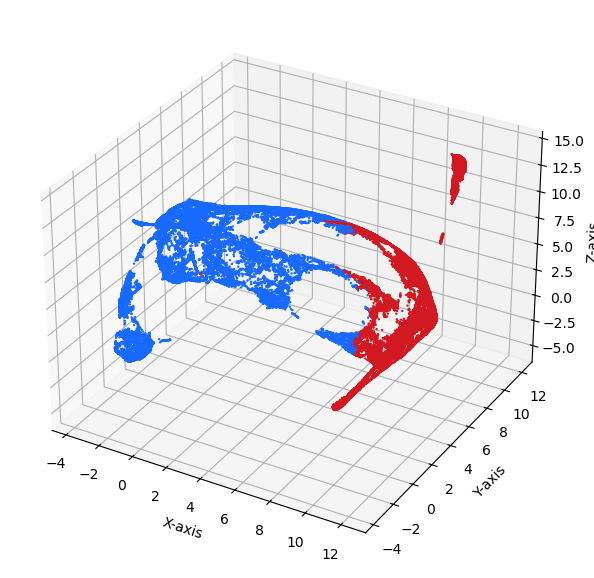

In [36]:
n_clusters = hyp_config.kmeans_original_hyps["n_clusters"]
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_kmeans_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


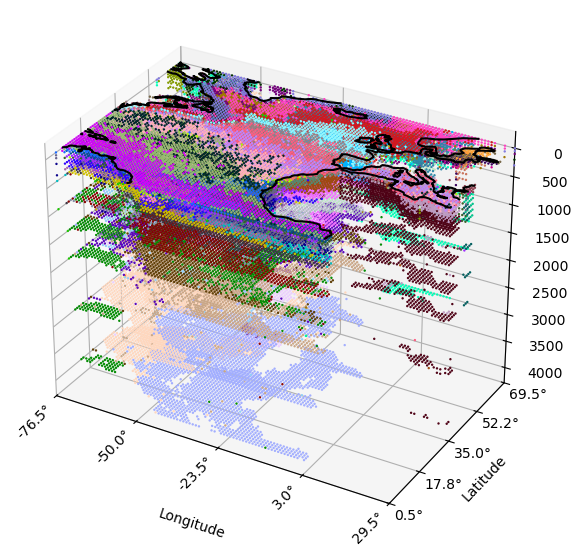

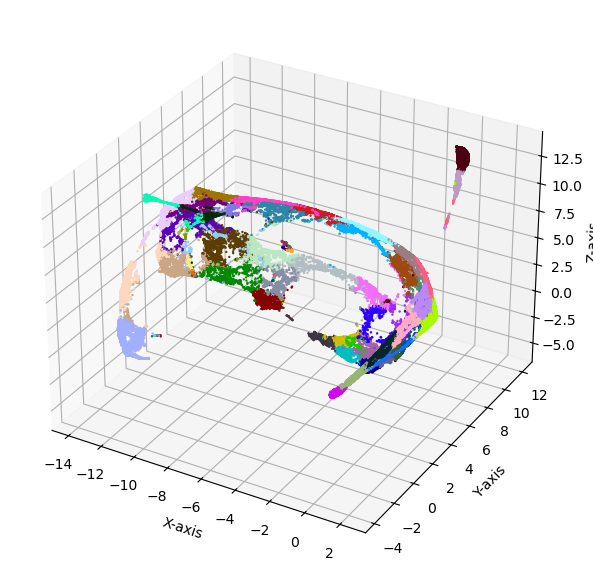

In [15]:
# Visualise highest n_clusters
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == 60]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=180, y=0, z=0, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_kmeans_original_60", figsize=(6, 6), 
                   fontsize=None, ticklabelsize=None, dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


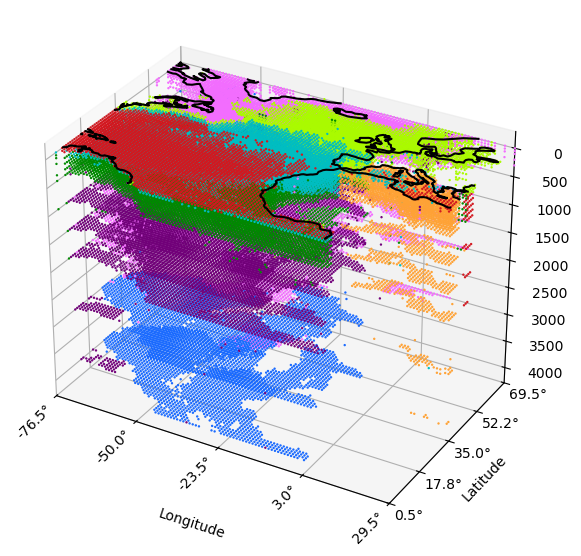

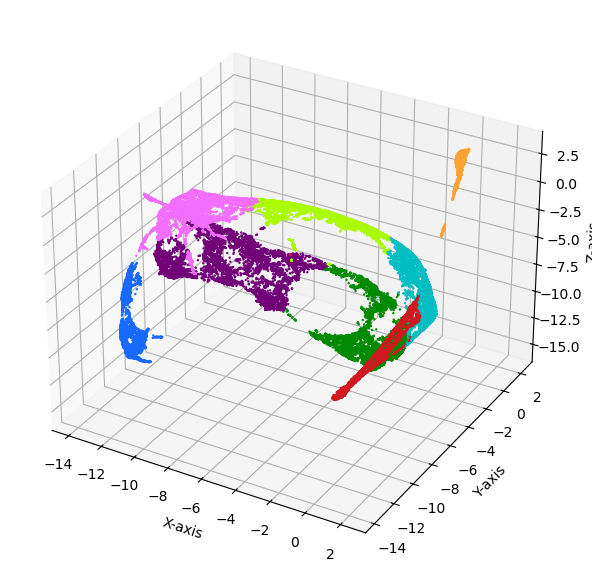

In [16]:
n_clusters = hyp_config.kmeans_umap_hyps["n_clusters"]
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_kmeans_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


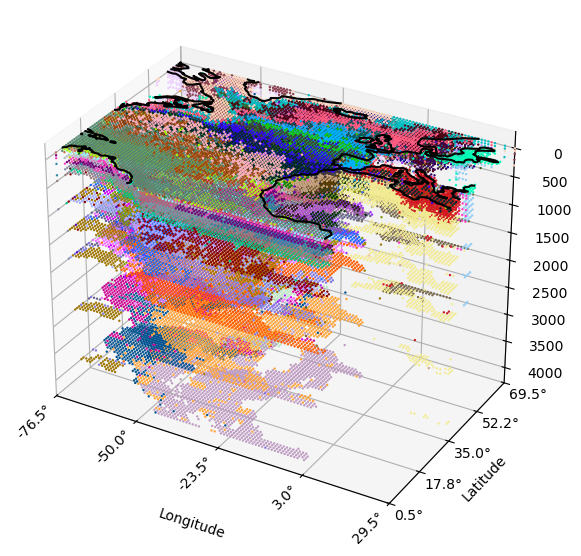

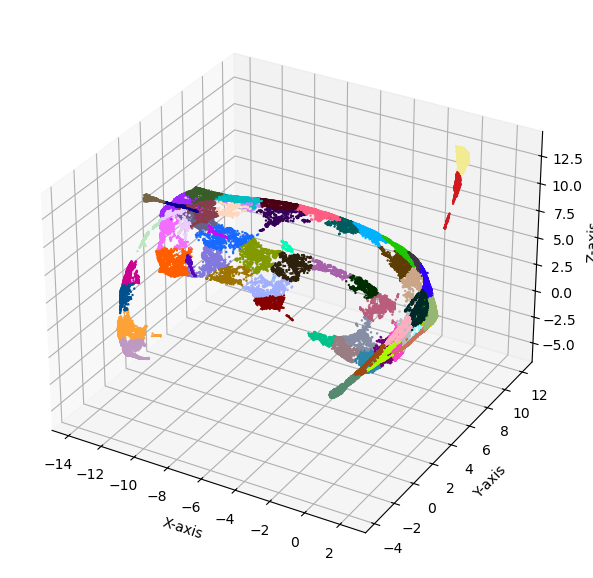

In [41]:
# Visualise highest n_clusters
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == 60]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=180, y=0, z=0, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_kmeans_umap_60", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# Agglomerative Ward

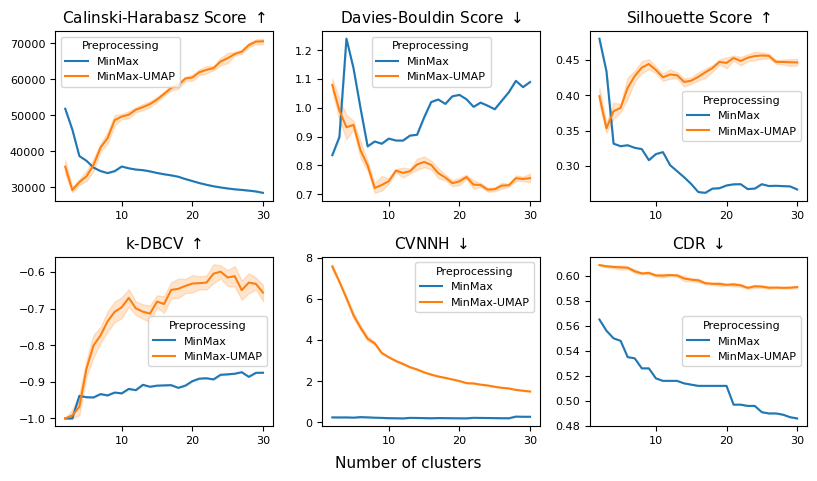

In [50]:
plot_score(df_ward, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_ward.png", dpi=1000)
plt.show()

## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


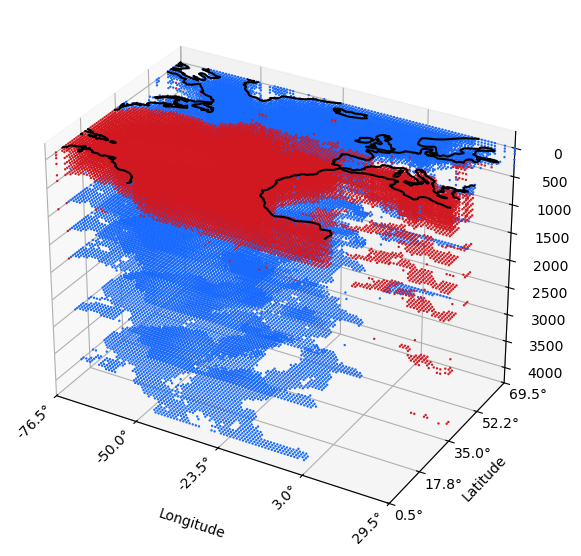

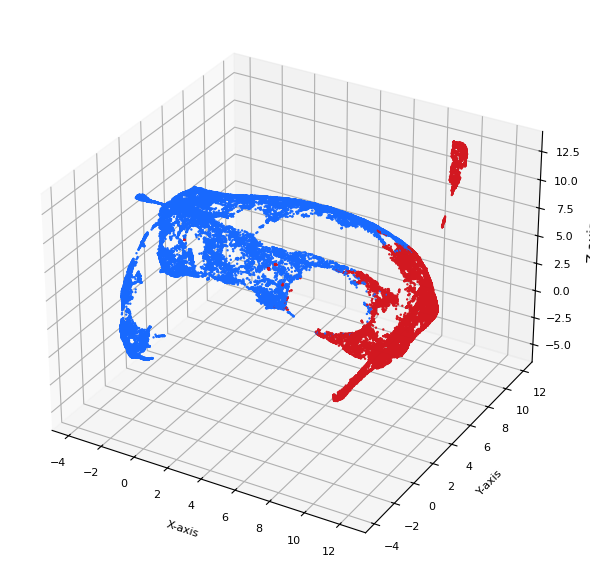

In [45]:
n_clusters = hyp_config.ward_original_hyps["n_clusters"]
temp = df_ward_labels[df_ward_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_ward_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


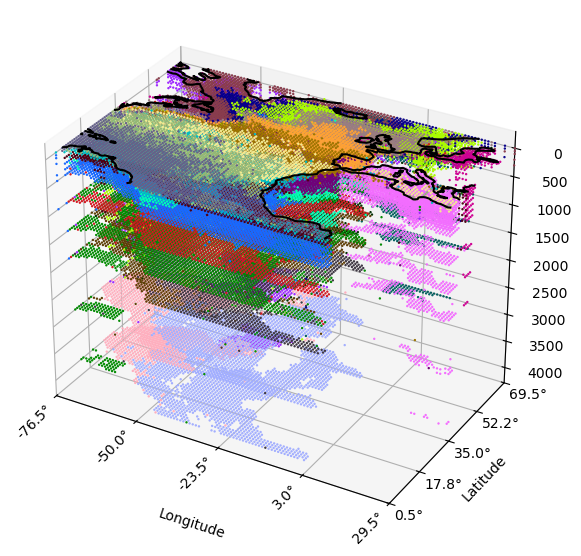

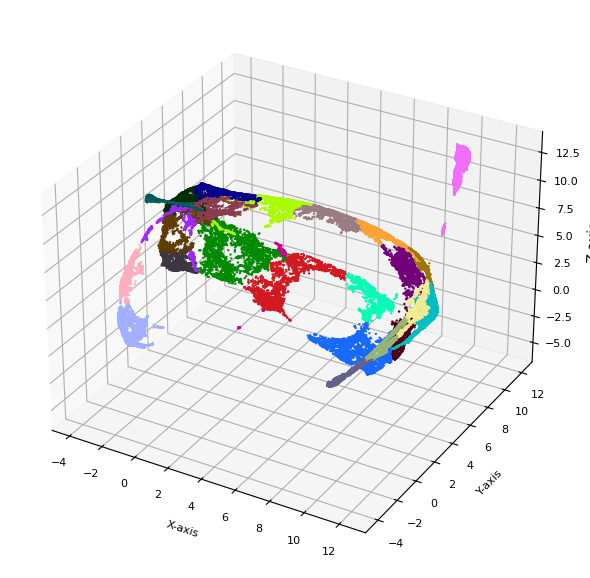

In [38]:
n_clusters = hyp_config.ward_umap_hyps["n_clusters"]
temp = df_ward_labels[df_ward_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=1)  # Rotate UMAP 
# temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_ward_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# Spatial Ward

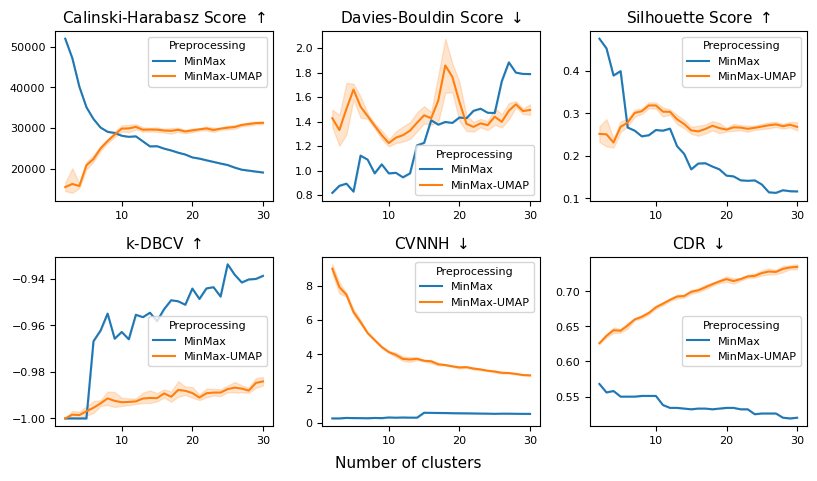

In [51]:
plot_score(df_spatial, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_spatial_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_spatial_ward.png", dpi=1000)
plt.show()

## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


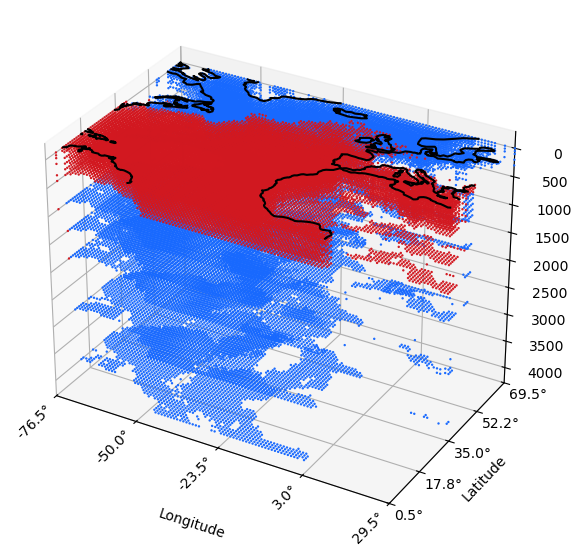

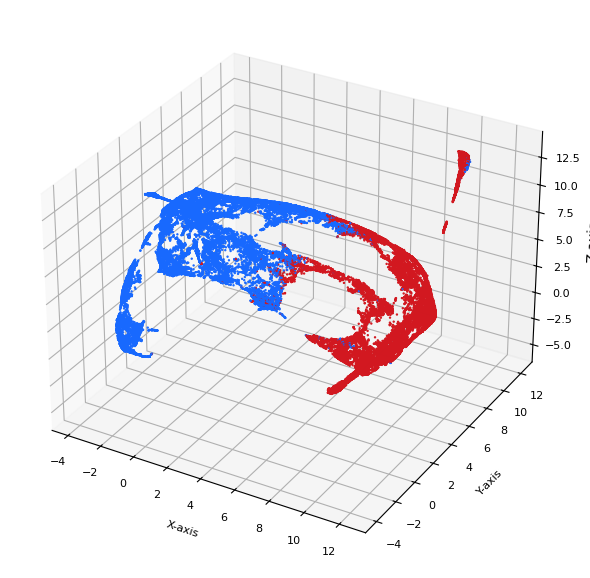

In [52]:
n_clusters = hyp_config.spatial_original_hyps["n_clusters"]
temp = df_spatial_labels[df_spatial_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_spatial_ward_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


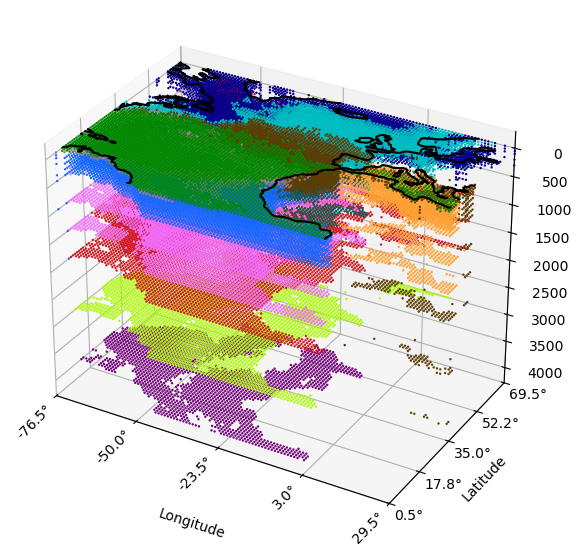

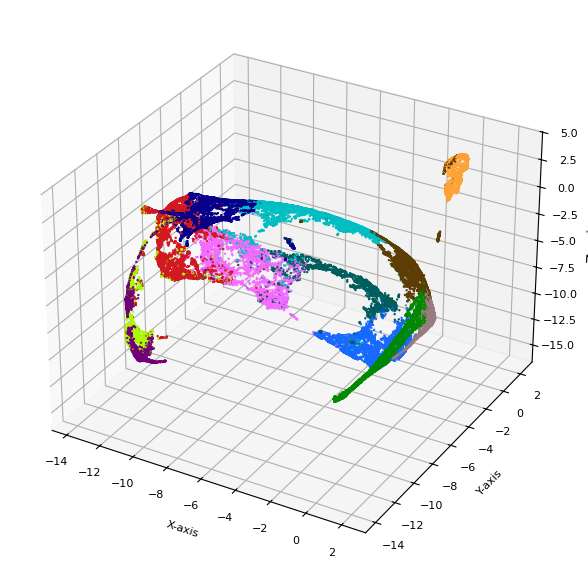

In [14]:
n_clusters = 12 # hyp_config.spatial_umap_hyps["n_clusters"]
temp = df_spatial_labels[df_spatial_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=-1)  # Rotate UMAP 
# temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_spatial_ward_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# DBSCAN

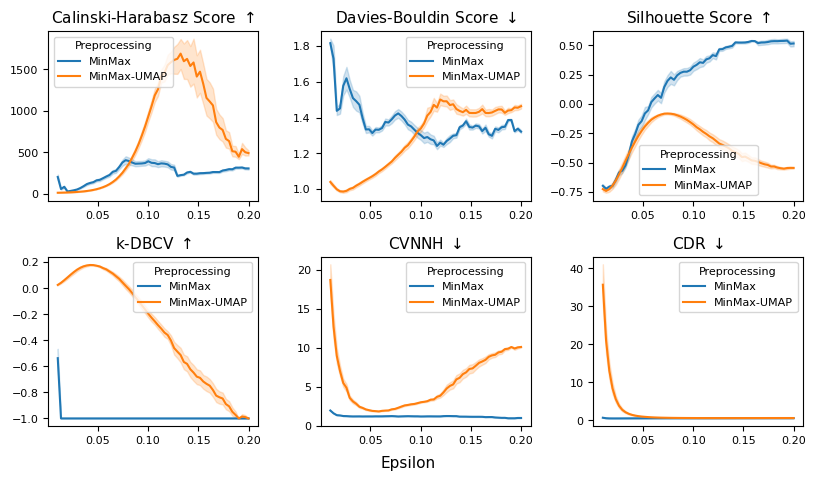

In [52]:
plot_score(df_dbscan, x="eps")
plt.savefig(f"{config.output_dir_plots}score_dbscan_eps.png")
plt.show()

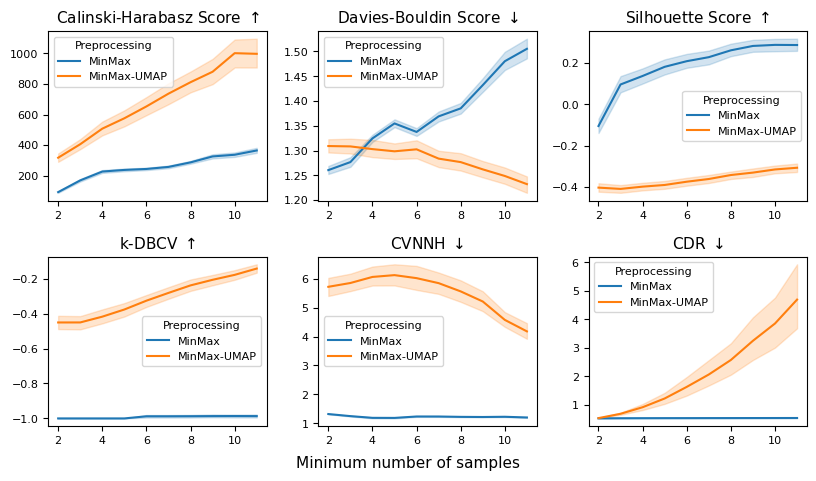

In [53]:
plot_score(df_dbscan, x="min_samples")
plt.savefig(f"{config.output_dir_plots}score_dbscan_min_samples.png")
plt.show()

## Heatmaps
The tuning of 2 parameters instead of one is more complex due to the interaction between the parameters. Therefore, considering plots displaying only one parameter is less descriptive of the actual behaviour. Therefore, we plot the following heatmap.

In [54]:
# Average scores over iterations
df_dbscan_i = df_dbscan.groupby(["eps", "min_samples", "preprocessing", "clustering"]).mean().drop("iteration", axis=1).reset_index()

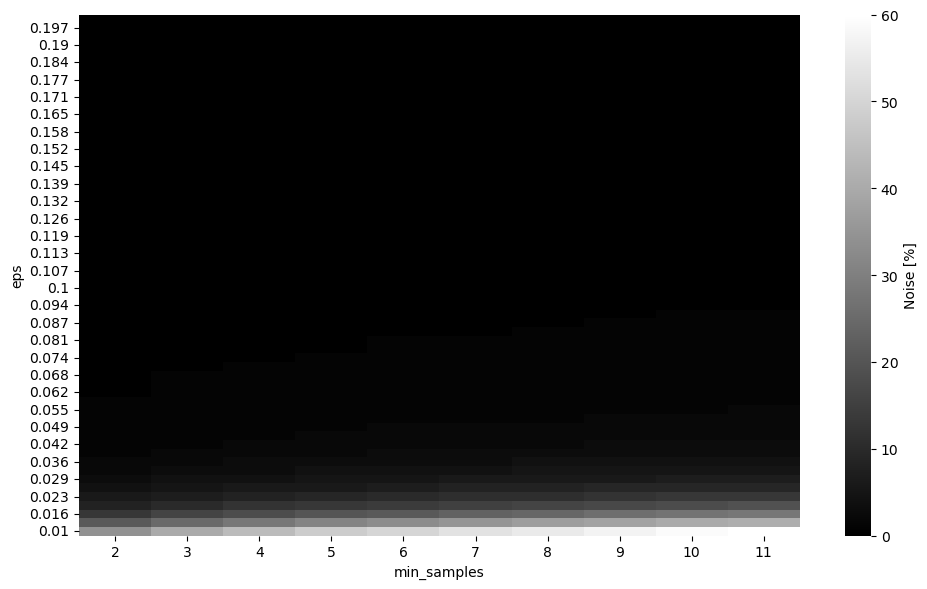

Maximum gradient for nnoise at (eps, min_samples) = (np.float64(0.01), np.float64(9.0))


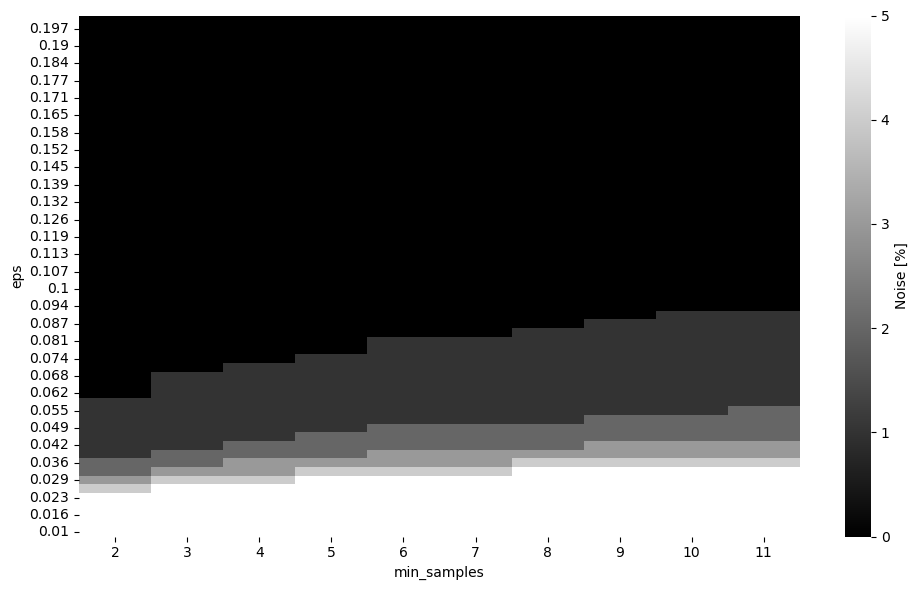

Maximum gradient (nnoise <=5) at (eps, min_samples) = (np.float64(0.01), np.float64(9.0))


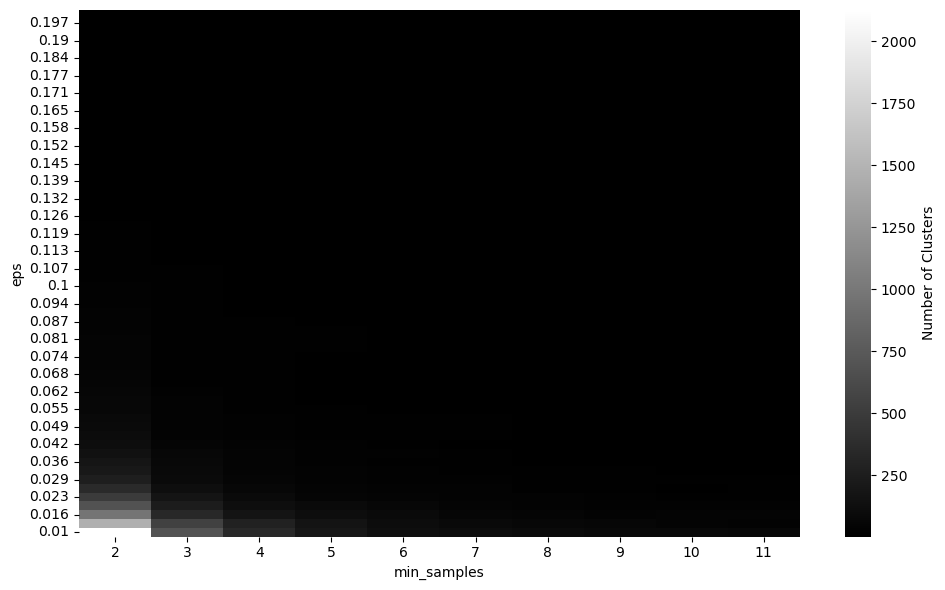

Maximum gradient at (eps, min_samples) = (np.float64(0.01), np.float64(2.0))


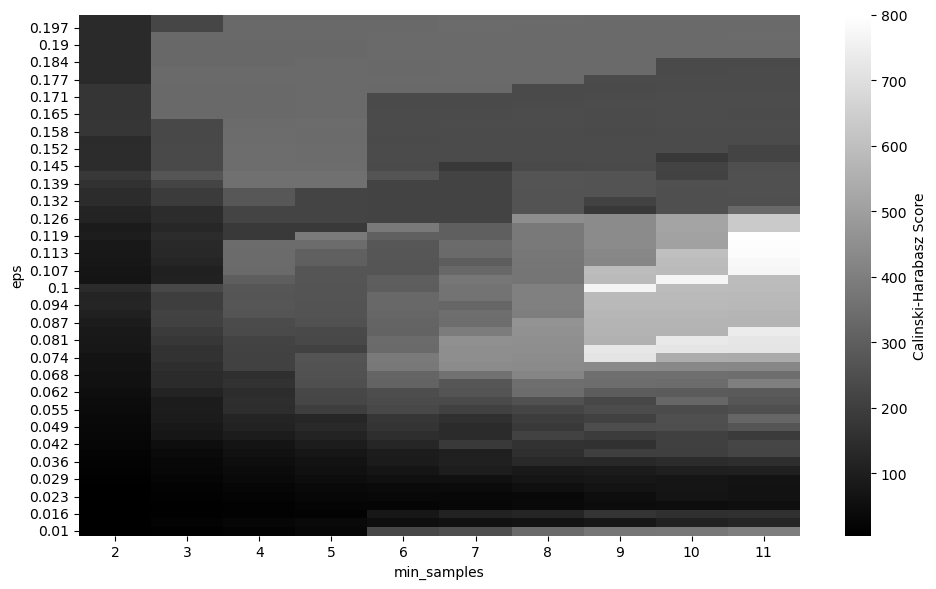

Maximum Calinski-Harabasz score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
698  0.119           11        minmax     dbscan        4.0        11.411032   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
698   78.498173      25.0       0.546            1.44              800.0   

     kdbcv  cvnn_hal   cdr  nnoise  
698   -1.0      0.98  0.54     0.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
698  0.119           11        minmax     dbscan        4.0        11.411032   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
698   78.498173      25.0       0.546            1.44              800.0   

     kdbcv  cvnn_hal   cdr  nnoise  
698   -1.0      0.98  0.54     0.0  


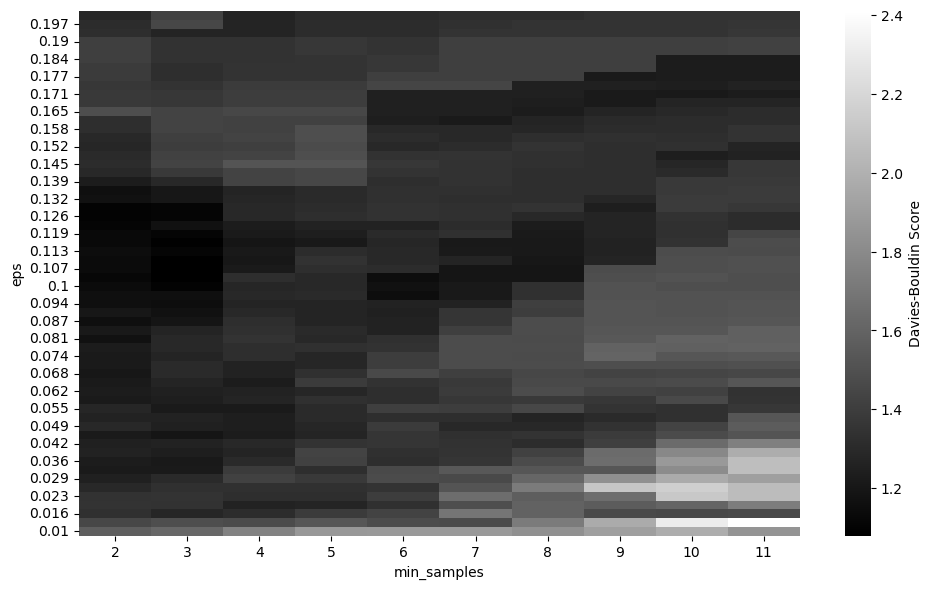

Minimum Davies-Bouldin score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
582  0.103            3        minmax     dbscan       12.0         9.828843   
602  0.107            3        minmax     dbscan       12.0        10.147473   
622  0.110            3        minmax     dbscan       11.0        10.429174   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
582   78.755524     83.33       0.383            1.08              108.0   
602   71.597635     83.33       0.384            1.08              107.0   
622   67.981681     81.82       0.380            1.08              120.0   

     kdbcv  cvnn_hal   cdr  nnoise  
582   -1.0      1.30  0.55     0.0  
602   -1.0      1.30  0.55     0.0  
622   -1.0      1.31  0.55     0.0  
Minimum Davies-Bouldin score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
582  0.103            3        minmax     dbscan       12.

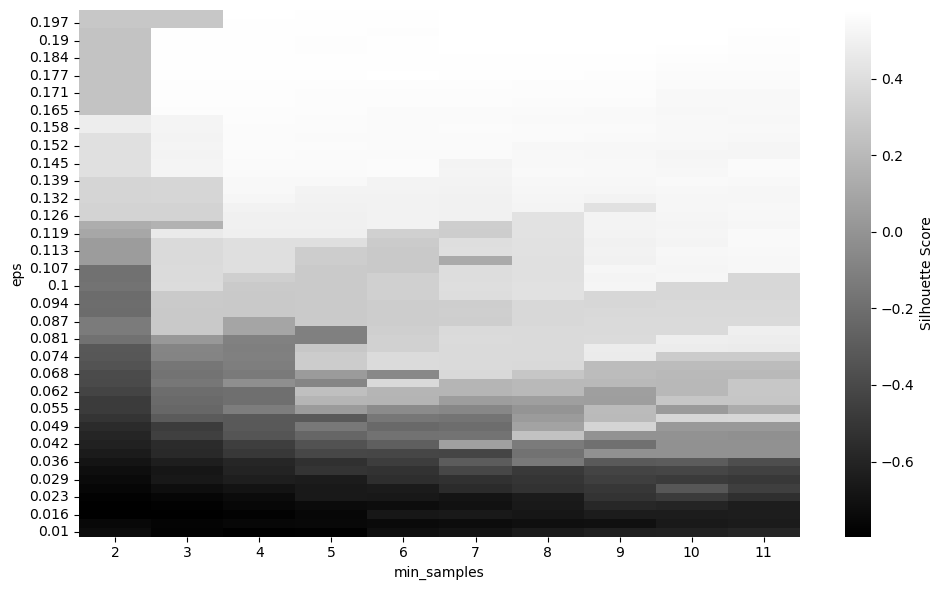

Maximum Silhouette score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1190  0.2            7        minmax     dbscan        3.0        16.423426   
1194  0.2            9        minmax     dbscan        3.0        16.446905   
1196  0.2           10        minmax     dbscan        3.0        16.352386   
1198  0.2           11        minmax     dbscan        3.0        16.578226   

      score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
1190   79.825300     66.67       0.579            1.32              338.0   
1194   79.327361     66.67       0.579            1.34              337.0   
1196   79.775249     66.67       0.579            1.34              337.0   
1198   79.379685     66.67       0.579            1.34              337.0   

      kdbcv  cvnn_hal   cdr  nnoise  
1190   -1.0      0.95  0.56     0.0  
1194   -1.0      0.96  0.56     0.0  
1196   -1.0      0.96  0.56     0.0  
1198   -1.0      0.96  0.56     0.0

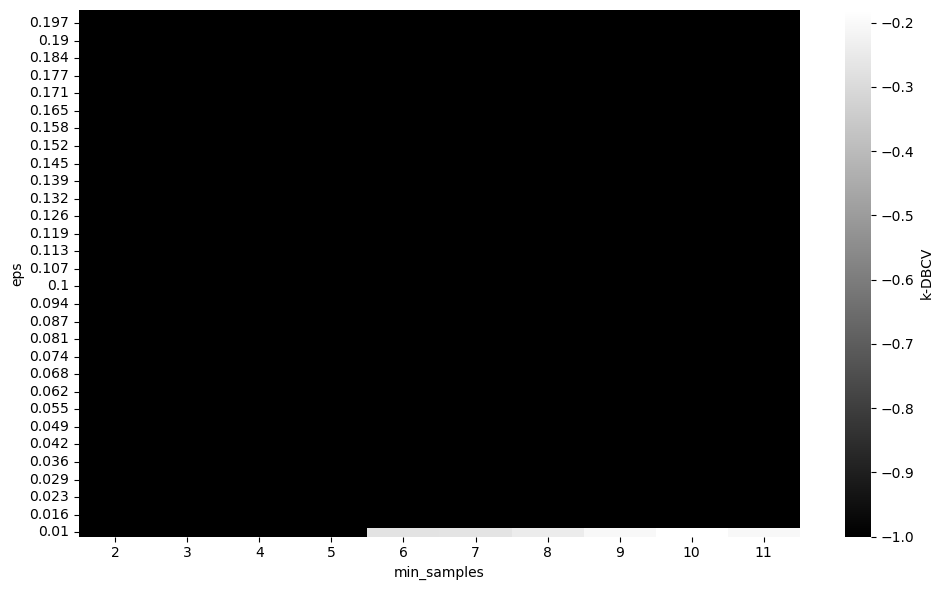

Maximum k-DBCV score here:      eps  min_samples preprocessing clustering  nclusters  clustering_time  \
16  0.01           10        minmax     dbscan       71.0         0.950675   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
16   73.874311     84.51      -0.617            1.98              375.0   

     kdbcv  cvnn_hal   cdr  nnoise  
16 -0.1802      1.91  0.78    59.0  
Maximum k-DBCV score (where nnoise<=5) here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
100   0.026            2        minmax     dbscan      355.0         2.312736   
102   0.026            3        minmax     dbscan      122.0         2.328451   
120   0.029            2        minmax     dbscan      260.0         2.626603   
122   0.029            3        minmax     dbscan       91.0         2.613229   
124   0.029            4        minmax     dbscan       50.0         2.623679   
...     ...          ...           ...        ...        ...

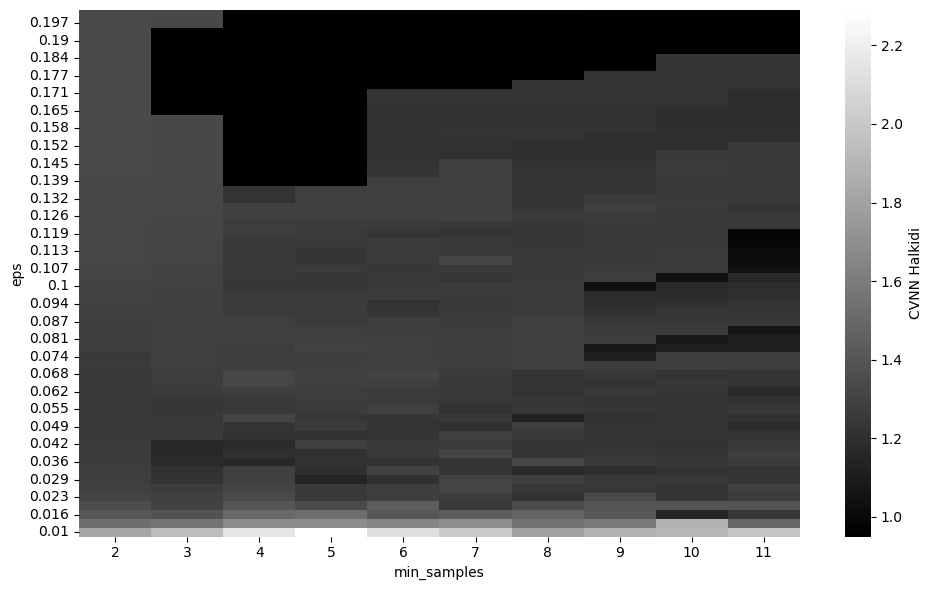

Maximum CVNN Halkidi score here:     eps  min_samples preprocessing clustering  nclusters  clustering_time  \
6  0.01            5        minmax     dbscan      188.0         0.953958   

   score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  kdbcv  \
6   31.779597     95.74      -0.786            1.87               27.0   -1.0   

   cvnn_hal   cdr  nnoise  
6      2.29  0.64    48.0  
Maximum CVNN Halkidi score (where nnoise<=5) here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
820   0.142            2        minmax     dbscan        7.0        13.026189   
840   0.145            2        minmax     dbscan        6.0        13.313272   
860   0.148            2        minmax     dbscan        6.0        13.441993   
880   0.152            2        minmax     dbscan        6.0        13.610297   
900   0.155            2        minmax     dbscan        6.0        13.826627   
920   0.158            2        minmax     dbscan       

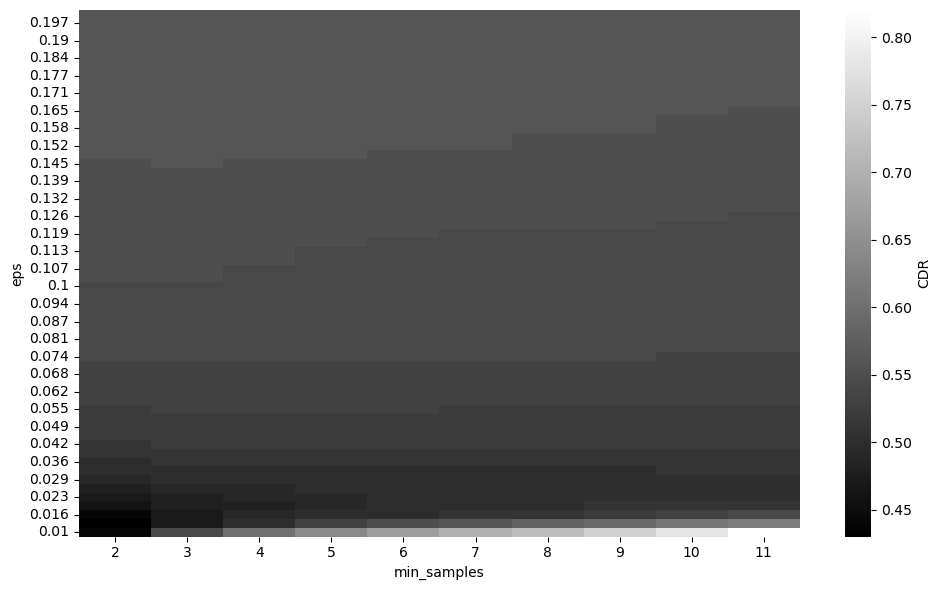

Maximum CDR score here:      eps  min_samples preprocessing clustering  nclusters  clustering_time  \
18  0.01           11        minmax     dbscan       64.0         0.949875   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
18   70.243528     81.25      -0.596            1.85              398.0   

     kdbcv  cvnn_hal   cdr  nnoise  
18 -0.2058      1.98  0.82    60.0  
Maximum CDR score (where nnoise<=5) here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
842   0.145            3        minmax     dbscan        4.0        13.247957   
860   0.148            2        minmax     dbscan        6.0        13.441993   
862   0.148            3        minmax     dbscan        4.0        13.457750   
864   0.148            4        minmax     dbscan        3.0        13.455486   
866   0.148            5        minmax     dbscan        3.0        13.497288   
...     ...          ...           ...        ...        ...      

In [55]:
# Plot score heatmap for clustering on original and scores on original
preproc = "minmax"
plt.rcParams["figure.figsize"] = (10, 6)

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
temp.kdbcv = temp.kdbcv.round(4)
temp.cvnn_hal = temp.cvnn_hal.round(2)
temp.cdr = temp.cdr.round(2)
t = temp[temp.nnoise <= 5]  # Results for less than 5% noise

# Noise fraction
field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)
plt.show()
print(f"Maximum gradient for nnoise at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum gradient (nnoise <=5) at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

# k-DBCV
field_kdbcv, vs_kdbcv = plot_heatmap(temp, x="min_samples", y="eps", color="kdbcv", title="", annot=False)
plt.show()
print(f"Maximum k-DBCV score here: {temp[temp.kdbcv == temp.kdbcv.max()]}")
print(f"Maximum k-DBCV score (where nnoise<=5) here: {t[t.kdbcv == t.kdbcv.max()]}")

# CVNN Halkidi
field_cvnn, vs_cvnn = plot_heatmap(temp, x="min_samples", y="eps", color="cvnn_hal", title="", annot=False)
plt.show()
print(f"Maximum CVNN Halkidi score here: {temp[temp.cvnn_hal == temp.cvnn_hal.max()]}")
print(f"Maximum CVNN Halkidi score (where nnoise<=5) here: {t[t.cvnn_hal == t.cvnn_hal.max()]}")

# CDR
field_cdr, vs_cdr = plot_heatmap(temp, x="min_samples", y="eps", color="cdr", title="", annot=False)
plt.show()
print(f"Maximum CDR score here: {temp[temp.cdr == temp.cdr.max()]}")
print(f"Maximum CDR score (where nnoise<=5) here: {t[t.cdr == t.cdr.max()]}")

In [56]:
# Optimal hyperparameter combinations according to different criteria (DBSCAN on minmax)
eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]

print("Hyperparameters for DBSCAN on MinMax (original) data")
ch_max = temp[temp["calinski_harabasz"] == temp["calinski_harabasz"].max()].iloc[0]
sh_max = temp[temp["silhouette"] == temp["silhouette"].max()].iloc[0]
db_min = temp[temp["davies_bouldin"] == temp["davies_bouldin"].min()].iloc[0]
nc_gradient = find_steepest_gradient(temp, value_col="nclusters")
nc_steep = temp[(temp.min_samples == nc_gradient[1]) & (temp.eps.round(3) == nc_gradient[0].round(3))].iloc[0]

print(f"  Highest CH score: eps={eps_array[np.abs(eps_array - ch_max.eps).argmin()].round(8)}, min_samples={ch_max['min_samples']}, CH={ch_max['calinski_harabasz']}, DB={ch_max['davies_bouldin'].round(2)}, SH={ch_max.silhouette.round(2)}, n_clusters={ch_max.nclusters}, nnoise={ch_max.nnoise}")
print(f"  Lowest DB score: eps={eps_array[np.abs(eps_array - db_min.eps).argmin()].round(8)}, min_samples={db_min['min_samples']}, CH={db_min['calinski_harabasz']}, DB={db_min['davies_bouldin'].round(2)}, SH={db_min.silhouette.round(2)}, n_clusters={db_min.nclusters}, nnoise={db_min.nnoise}")
print(f"  Highest SH score: eps={eps_array[np.abs(eps_array - sh_max.eps).argmin()].round(8)}, min_samples={sh_max['min_samples']}, CH={sh_max['calinski_harabasz']}, DB={sh_max['davies_bouldin'].round(2)}, SH={sh_max.silhouette.round(2)}, n_clusters={sh_max.nclusters}, nnoise={sh_max.nnoise}")
print(f"  Steepest #clusters gradient: eps={eps_array[np.abs(eps_array - nc_steep.eps).argmin()].round(8)}, min_samples={nc_steep['min_samples']}, CH={nc_steep['calinski_harabasz']}, DB={nc_steep['davies_bouldin'].round(2)}, SH={nc_steep.silhouette.round(2)}, n_clusters={nc_steep.nclusters}, nnoise={nc_steep.nnoise}")

Hyperparameters for DBSCAN on MinMax (original) data
  Highest CH score: eps=0.11949153, min_samples=11, CH=800.0, DB=1.44, SH=0.55, n_clusters=4.0, nnoise=0.0
  Lowest DB score: eps=0.10338983, min_samples=3, CH=108.0, DB=1.08, SH=0.38, n_clusters=12.0, nnoise=0.0
  Highest SH score: eps=0.2, min_samples=7, CH=338.0, DB=1.32, SH=0.58, n_clusters=3.0, nnoise=0.0
  Steepest #clusters gradient: eps=0.01, min_samples=2, CH=5.0, DB=1.57, SH=-0.73, n_clusters=2127.0, nnoise=34.0


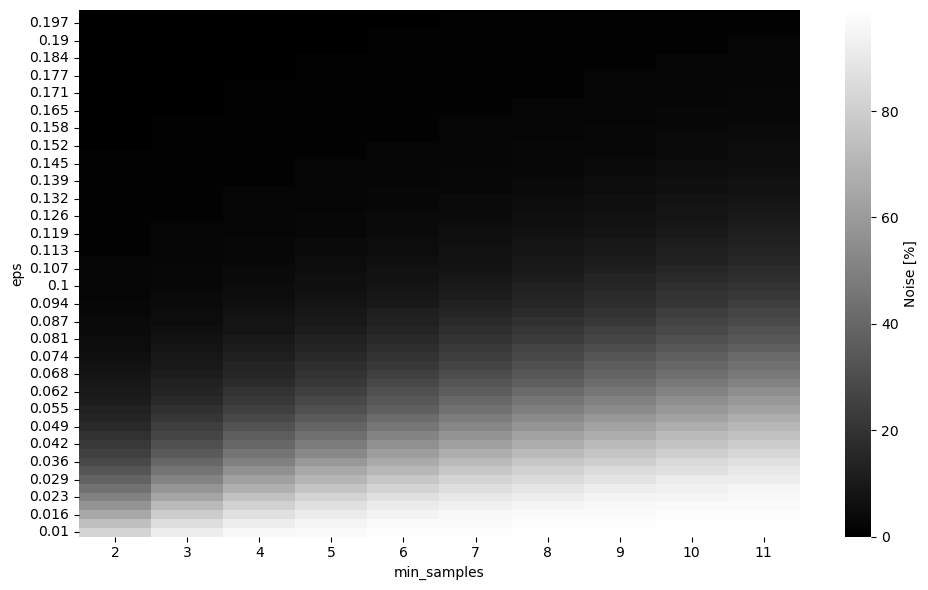

Maximum noise gradient at (eps, min_samples) = (np.float64(0.02), np.float64(2.0))


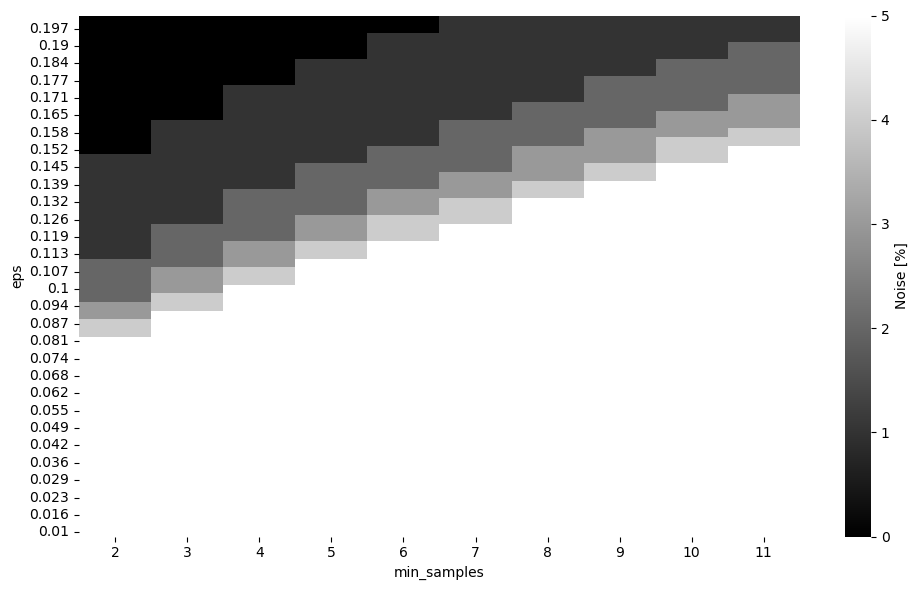

Maximum noise<5% gradient at (eps, min_samples) = (np.float64(0.02), np.float64(2.0))


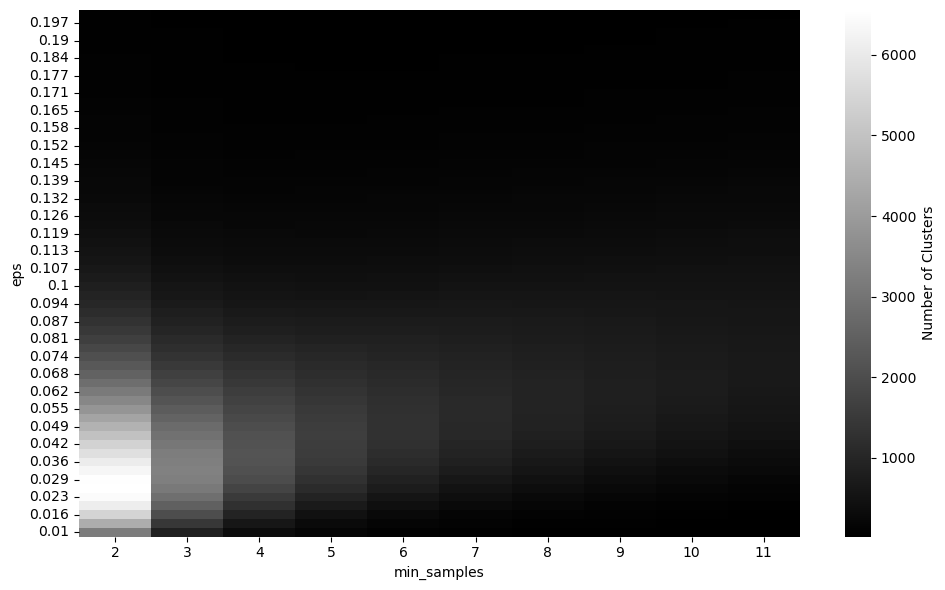

Maximum nclusters gradient at (eps, min_samples) = (np.float64(0.02), np.float64(2.0))


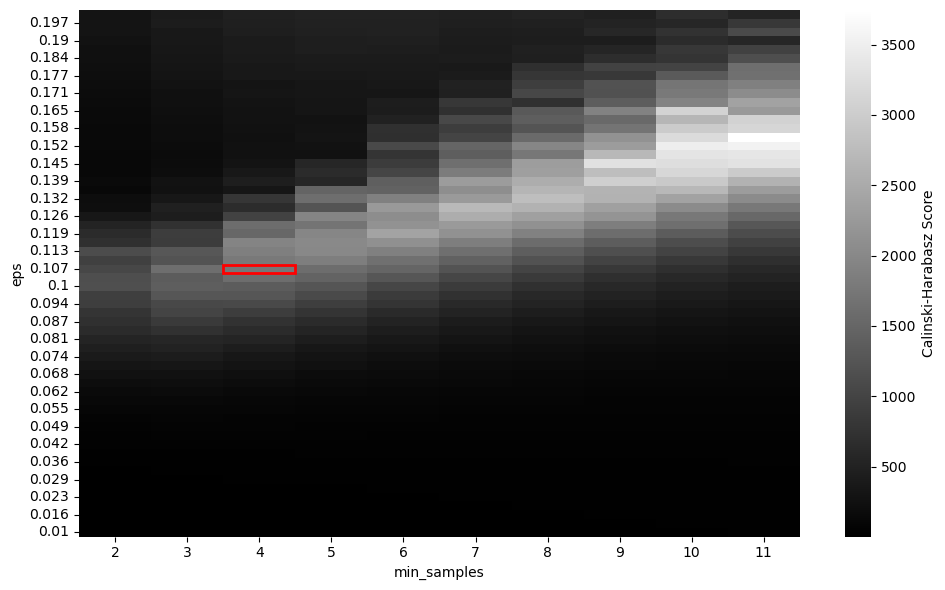

Maximum Calinski-Harabasz score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
919  0.155           11   minmax_umap     dbscan      128.0        12.322406   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
919   79.810333    51.066      -0.197            1.45             3746.0   

        kdbcv  cvnn_hal     cdr  nnoise  
919 -0.347377    3.5799  0.5872     4.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
919  0.155           11   minmax_umap     dbscan      128.0        12.322406   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
919   79.810333    51.066      -0.197            1.45             3746.0   

        kdbcv  cvnn_hal     cdr  nnoise  
919 -0.347377    3.5799  0.5872     4.0  


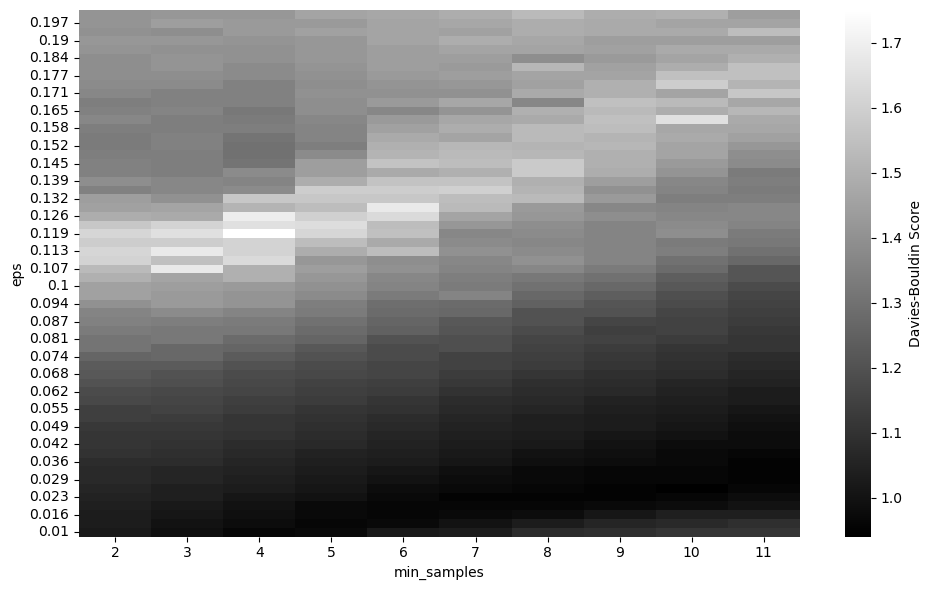

Minimum Davies-Bouldin score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
117  0.026           10   minmax_umap     dbscan      186.0        11.375589   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
117   25.126877    96.944      -0.786            0.94               25.0   

       kdbcv  cvnn_hal     cdr  nnoise  
117  0.05413    7.6001  7.7677    93.0  
Minimum Davies-Bouldin score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
865  0.148            4   minmax_umap     dbscan       95.0        12.452569   
885  0.152            4   minmax_umap     dbscan       90.0        12.625271   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
865   56.719254    74.910      -0.590             1.3              259.0   
885   58.423406    73.433      -0.588             1.3              254.0   

     kdbcv  cvnn_hal     cdr  nnoise  
865   -

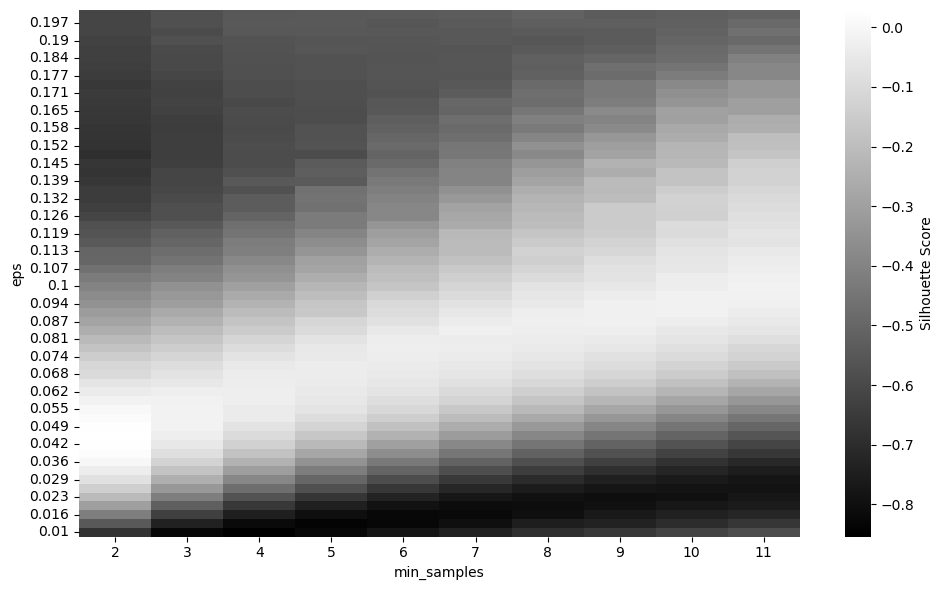

Maximum Silhouette score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
221  0.045            2   minmax_umap     dbscan     4969.0        11.543797   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
221   42.596054    97.768       0.029            1.11               45.0   

        kdbcv  cvnn_hal     cdr  nnoise  
221  0.167732    1.4698  0.4536    19.0  
Maximum Silhouette score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
859  0.145           11   minmax_umap     dbscan      171.0        12.845001   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
859   68.243979    54.659       -0.14            1.38             3311.0   

        kdbcv  cvnn_hal     cdr  nnoise  
859 -0.287045    3.0286  0.5898     5.0  


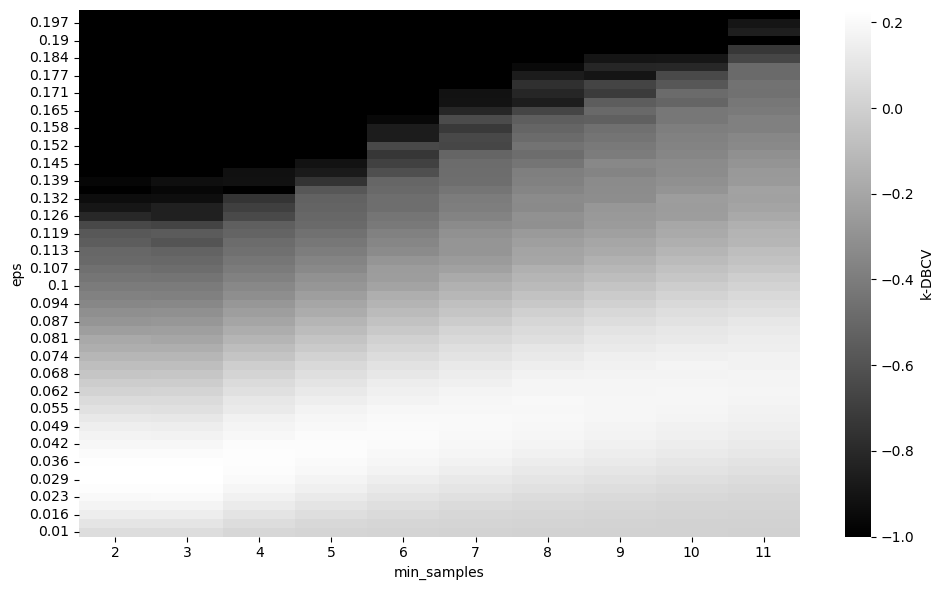

Maximum k-DBCV score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
123  0.029            3   minmax_umap     dbscan     3281.0        11.618261   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
123   33.006078    99.086      -0.247            1.06               16.0   

        kdbcv  cvnn_hal     cdr  nnoise  
123  0.228694    1.8616  0.7277    51.0  
Maximum k-DBCV score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
421  0.078            2   minmax_umap     dbscan     1843.0        11.796433   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
421   50.798389    91.921      -0.178            1.31              469.0   

        kdbcv  cvnn_hal     cdr  nnoise  
421 -0.160911    2.5745  0.5061     5.0  


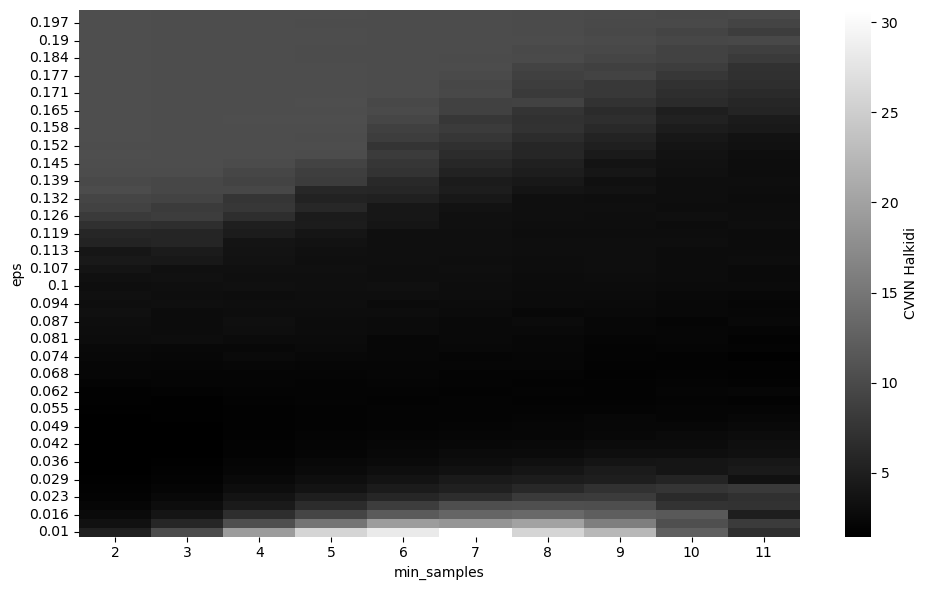

Maximum CVNN Halkidi score here:      eps  min_samples preprocessing clustering  nclusters  clustering_time  \
11  0.01            7   minmax_umap     dbscan       61.0        11.438046   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
11   24.425427    98.346      -0.738            1.03               14.0   

       kdbcv  cvnn_hal      cdr  nnoise  
11  0.013986   30.6662  35.9978    98.0  
Maximum CVNN Halkidi score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
941  0.161            2   minmax_umap     dbscan      124.0        12.440223   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
941   58.700586    85.079      -0.664            1.37              153.0   

     kdbcv  cvnn_hal     cdr  nnoise  
941   -1.0   10.4175  0.5851     0.0  


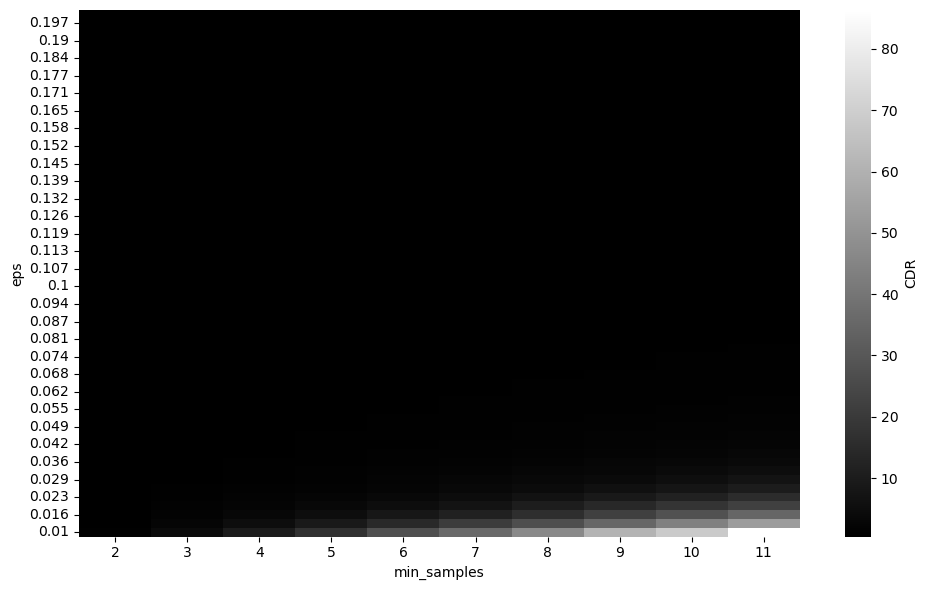

Maximum CDR score here:      eps  min_samples preprocessing clustering  nclusters  clustering_time  \
19  0.01           11   minmax_umap     dbscan       21.0        11.294302   

    score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
19   24.584892    94.785      -0.586            1.11               18.0   

       kdbcv  cvnn_hal      cdr  nnoise  
19  0.007032    6.8607  86.3598    99.0  
Maximum CDR score (where nnoise<=5) here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1177  0.197           10   minmax_umap     dbscan       45.0        12.416246   

      score_time   confetti  silhouette  davies_bouldin  calinski_harabasz  \
1177   57.069553  56.352222      -0.522            1.46              566.0   

      kdbcv  cvnn_hal       cdr  nnoise  
1177   -1.0  9.832556  0.595667     1.0  


In [57]:
# Plot score heatmap for clustering on embedding
preproc = "minmax_umap"
plt.rcParams["figure.figsize"] = (10, 6)

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
t = temp[temp.nnoise <= 5]

# Noise fraction
field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False) 
plt.show()
print(f"Maximum noise gradient at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum noise<5% gradient at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum nclusters gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(hyp_config.dbscan_umap_hyps["eps"], 3), hyp_config.dbscan_umap_hyps["min_samples"]))
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_calinski.png")
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_davies_bouldin.png")
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_silhouette.png")
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

# k-DBCV
field_kdbcv, vs_kdbcv = plot_heatmap(temp, x="min_samples", y="eps", color="kdbcv", title="", annot=False)
plt.show()
print(f"Maximum k-DBCV score here: {temp[temp.kdbcv == temp.kdbcv.max()]}")
print(f"Maximum k-DBCV score (where nnoise<=5) here: {t[t.kdbcv == t.kdbcv.max()]}")

# CVNN Halkidi
field_cvnn, vs_cvnn = plot_heatmap(temp, x="min_samples", y="eps", color="cvnn_hal", title="", annot=False)
plt.show()
print(f"Maximum CVNN Halkidi score here: {temp[temp.cvnn_hal == temp.cvnn_hal.max()]}")
print(f"Maximum CVNN Halkidi score (where nnoise<=5) here: {t[t.cvnn_hal == t.cvnn_hal.max()]}")

# CDR
field_cdr, vs_cdr = plot_heatmap(temp, x="min_samples", y="eps", color="cdr", title="", annot=False)
plt.show()
print(f"Maximum CDR score here: {temp[temp.cdr == temp.cdr.max()]}")
print(f"Maximum CDR score (where nnoise<=5) here: {t[t.cdr == t.cdr.max()]}")

In [58]:
# Optimal hyperparameter combinations according to different criteria (DBSCAN on minmax-UMAP)
eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]

print("Hyperparameters for DBSCAN on minmax_umap (embedded) data")
ch_max = temp[temp["calinski_harabasz"] == temp["calinski_harabasz"].max()].iloc[0]
sh_max = temp[temp["silhouette"] == temp["silhouette"].max()].iloc[0]
db_min = temp[temp["davies_bouldin"] == temp["davies_bouldin"].min()].iloc[0]
nc_gradient = find_steepest_gradient(temp, value_col="nclusters")
nc_steep = temp[(temp.min_samples == nc_gradient[1]) & (temp.eps.round(3) == nc_gradient[0].round(3))].iloc[0]

print(f"  Highest CH score: eps={eps_array[np.abs(eps_array - ch_max.eps).argmin()].round(8)}, min_samples={ch_max['min_samples']}, CH={ch_max['calinski_harabasz']}, DB={ch_max['davies_bouldin'].round(2)}, SH={ch_max.silhouette.round(2)}, n_clusters={ch_max.nclusters}, nnoise={ch_max.nnoise}")
print(f"  Lowest DB score: eps={eps_array[np.abs(eps_array - db_min.eps).argmin()].round(8)}, min_samples={db_min['min_samples']}, CH={db_min['calinski_harabasz']}, DB={db_min['davies_bouldin'].round(2)}, SH={db_min.silhouette.round(2)}, n_clusters={db_min.nclusters}, nnoise={db_min.nnoise}")
print(f"  Highest SH score: eps={eps_array[np.abs(eps_array - sh_max.eps).argmin()].round(8)}, min_samples={sh_max['min_samples']}, CH={sh_max['calinski_harabasz']}, DB={sh_max['davies_bouldin'].round(2)}, SH={sh_max.silhouette.round(2)}, n_clusters={sh_max.nclusters}, nnoise={sh_max.nnoise}")
print(f"  Steepest #clusters gradient: eps={eps_array[np.abs(eps_array - nc_steep.eps).argmin()].round(8)}, min_samples={nc_steep['min_samples']}, CH={nc_steep['calinski_harabasz']}, DB={nc_steep['davies_bouldin'].round(2)}, SH={nc_steep.silhouette.round(2)}, n_clusters={nc_steep.nclusters}, nnoise={nc_steep.nnoise}")

Hyperparameters for DBSCAN on minmax_umap (embedded) data
  Highest CH score: eps=0.15491525, min_samples=11, CH=3746.0, DB=1.45, SH=-0.2, n_clusters=128.0, nnoise=4.0
  Lowest DB score: eps=0.02610169, min_samples=10, CH=25.0, DB=0.94, SH=-0.79, n_clusters=186.0, nnoise=93.0
  Highest SH score: eps=0.04542373, min_samples=2, CH=45.0, DB=1.11, SH=0.03, n_clusters=4969.0, nnoise=19.0
  Steepest #clusters gradient: eps=0.01966102, min_samples=2, CH=6.0, DB=1.04, SH=-0.3, n_clusters=6072.0, nnoise=57.0


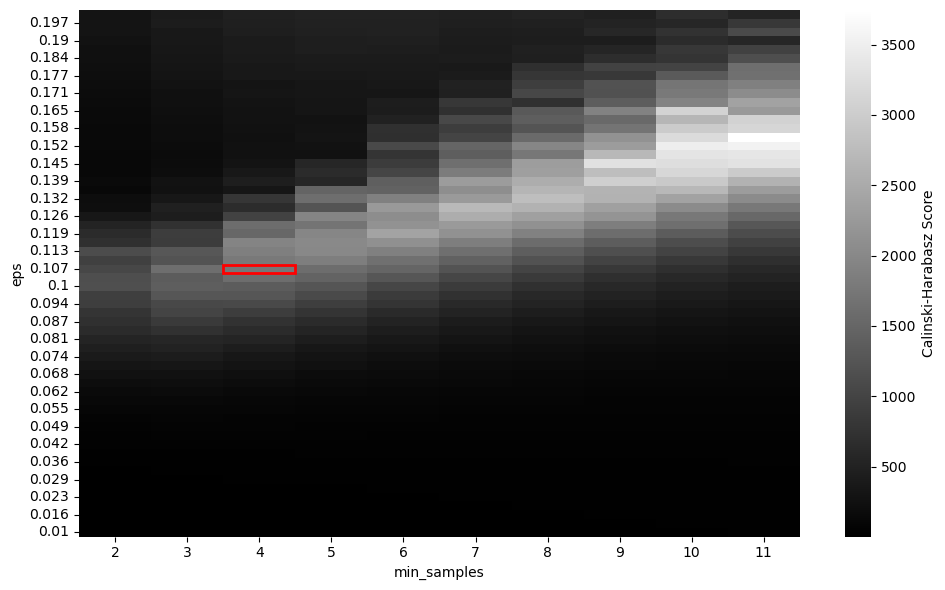

Maximum Calinski-Harabasz score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
919  0.155           11   minmax_umap     dbscan      128.0        12.322406   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
919   79.810333    51.066      -0.197            1.45             3746.0   

        kdbcv  cvnn_hal     cdr  nnoise  
919 -0.347377    3.5799  0.5872     4.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
919  0.155           11   minmax_umap     dbscan      128.0        12.322406   

     score_time  confetti  silhouette  davies_bouldin  calinski_harabasz  \
919   79.810333    51.066      -0.197            1.45             3746.0   

        kdbcv  cvnn_hal     cdr  nnoise  
919 -0.347377    3.5799  0.5872     4.0  


In [59]:
# Plot CH heatmap for DBSCAN on MinMax-UMAP
preproc = "minmax_umap"

# Figure size
plt.rcParams["figure.figsize"] = (10, 10*0.6)  

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
t = temp[temp.nnoise <= 5]

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(hyp_config.dbscan_umap_hyps["eps"], 3), hyp_config.dbscan_umap_hyps["min_samples"]))
plt.savefig(f"{config.output_dir_plots_high_res}{preproc}_dbscan_sweep_calinski.png", dpi=1000)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")


## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


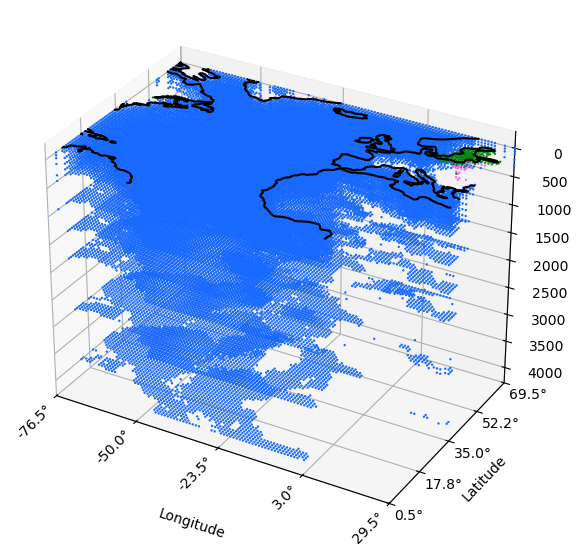

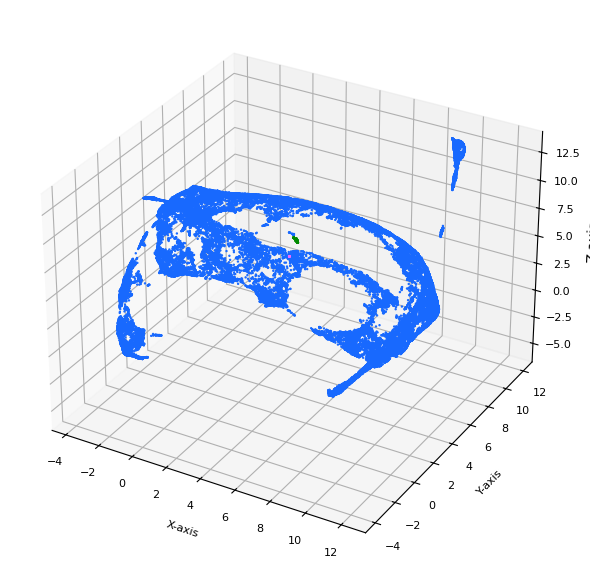

In [63]:
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_original_hyps, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"minmax": "label"})

temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label

coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_dbscan_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


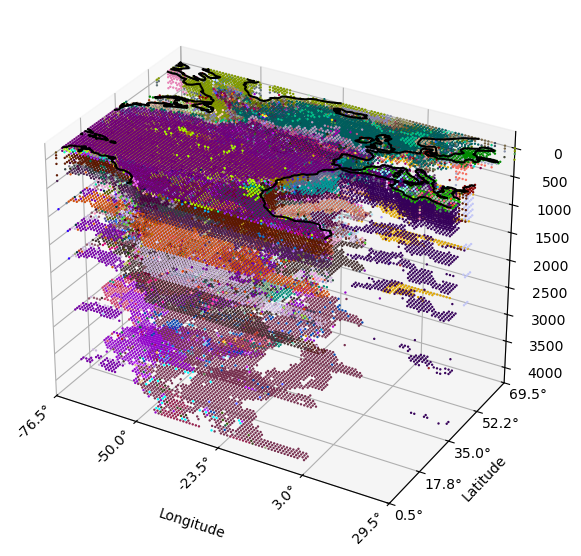

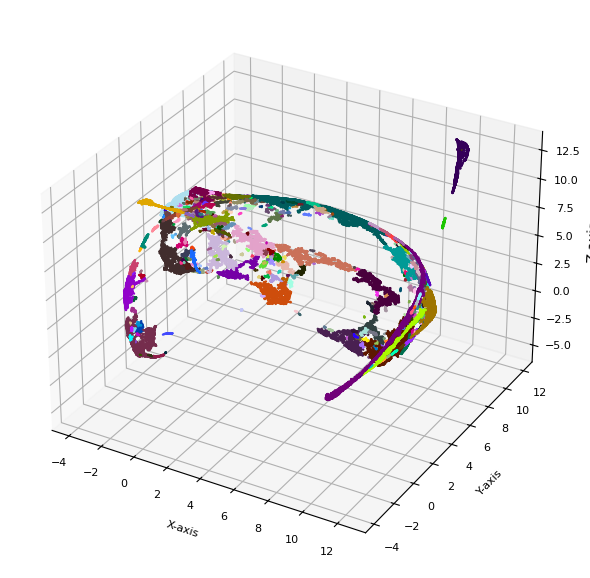

In [64]:
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_umap_hyps, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"minmax_umap": "label"})

temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_dbscan_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Confetti Plot

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


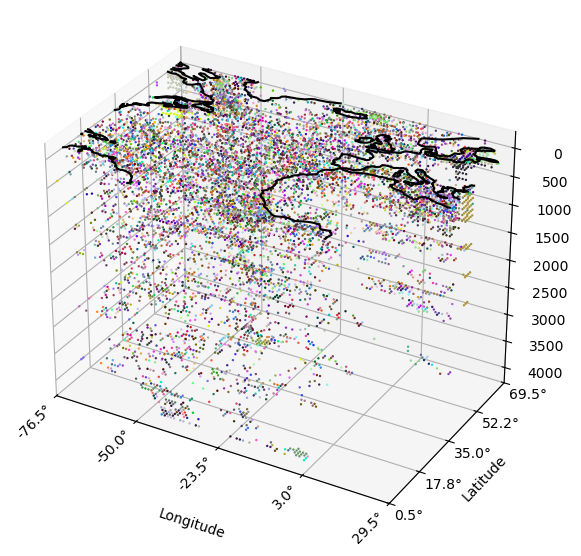

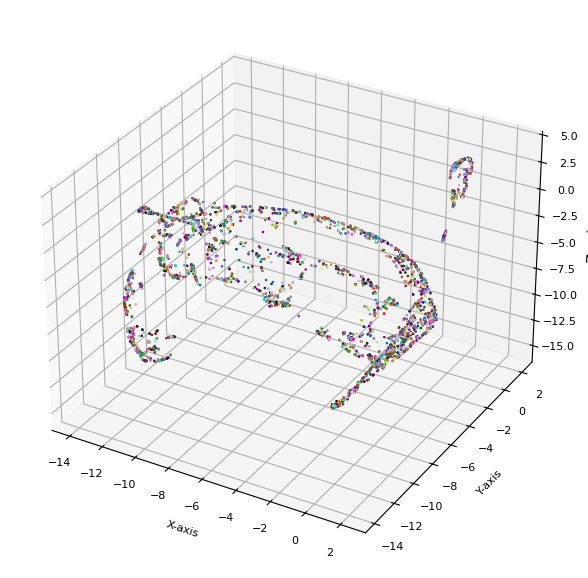

In [65]:
query_str = get_query_string_hyps_filter(hyp_dict={"eps": 0.01, "min_samples": 2}, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"minmax_umap": "label"})

temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label
temp[["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=0, factor=-1)

coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_confetti", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)